# Deep Q-Networks. Scaling Value-Based RL

## Recap and Motivation

Tabular Q-learning rests on the Bellman optimality equation
$$Q^*(s, a) = \mathbb{E}_{s' \sim P(\cdot \mid s, a)} \left[ r + \gamma \max_{a'} Q^*(s', a') \right]$$

and the incremental update
$$Q(s, a) \leftarrow Q(s, a) + \alpha \left( r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right).$$

Each value is maintained in a single table entry.

This works when $|\mathcal{S}|$ and $|\mathcal{A}|$ are small and every $(s, a)$ pair can be revisited often enough.

### Scaling to larger state spaces

Recall the CartPole environment, where the goal is to balance a pole on a moving cart on a continuous axis.

![CartPole](https://gymnasium.farama.org/_images/cart_pole.gif)

In [1]:
import gymnasium as gym

env = gym.make("CartPole-v1", render_mode='rgb_array')
print("Observation space", env.observation_space)
print("Action space     ", env.action_space)

Observation space Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space      Discrete(2)


The state is described by 4 continuous variables. Tabular Q-learning would require binning.

_Question_. For a four-dimensional state with $k$ bins per dimension, how many cells does the table have? What happens as $k$ grows or the dimensionality increases?

A tabular approach forces us to commit to a fixed grid resolution. The table size grows exponentially in the number of dimensions, and two states that are nearly identical in the underlying physics fall in different cells and are learned entirely separately.

## Background: Neural Networks as Function Approximators

A neural network is a parametric function $f_\theta: \mathbb{R}^d \to \mathbb{R}^k$ built by stacking linear maps and elementwise nonlinearities (we use ReLU below). The parameters $\theta$ are the entries of those linear maps. Given a target output $y$ for an input $x$, we tune $\theta$ by gradient descent on a loss such as $L(\theta) = (f_\theta(x) - y)^2$, computing $\nabla_\theta L$ via backpropagation and updating $\theta \leftarrow \theta - \eta \nabla_\theta L$ with learning rate $\eta$. See [this demo](https://colab.research.google.com/drive/1kFUIGuL6tXuVV_t0EqlHA74exJQmSlMf#scrollTo=NytiV67h0HFP) to understand $\eta$'s effect in gradient descent.

Two properties matter for us.

- **Universal approximation**. A sufficiently wide and deep network can represent any reasonable function. The networks in this tutorial are small (one or two hidden layers of a few dozen units).
- **Generalization**. Inputs that are close in input space tend to produce close outputs. A small change to $\theta$ adjusts predictions at many (sometimes infinite) inputs at once, which a lookup table cannot do.

### Multi-Layer Perceptron (MLP)

A Multi-Layer Perceptron (MLP) is a series of matrix multiplications separated by an elementwise nonlinearity. For our Q-network, the input is the state vector $s$, the output is a vector of $|\mathcal{A}|$ Q-values (one per action), and one or two **hidden layers** sit in between.

![mlp](images/mlp_colorful.png)

Concretely, a two-hidden-layer MLP with hidden width $h$ computes
$$Q_\theta(s, \cdot) = W_3 \, \mathrm{ReLU}(W_2 \, \mathrm{ReLU}(W_1 s + b_1) + b_2) + b_3,$$
where $\theta = \{W_1, b_1, W_2, b_2, W_3, b_3\}$ are the learnable parameters. We omit the activation on the output layer because Q-values can take any real value.

### PyTorch

[PyTorch](https://pytorch.org/) is a popular open-source library for building, training, and testing neural networks. We will define our Q-network as a PyTorch `nn.Module`.

In [2]:
from torch import nn

class QNet(nn.Module):
    def __init__(self, in_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)

qnet = QNet(in_dim=4, n_actions=2, hidden=8)
qnet

QNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
)

Calling `qnet` on an input vector of size 10 will output a vector of size 2

In [3]:
import torch

inp = torch.tensor([0.5] * 4)
out = qnet(inp)
out

tensor([0.0137, 0.1236], grad_fn=<ViewBackward0>)

Note the `grad_fn` field in the output tensor. PyTorch accumulates the operations executed on the input tensor, enabling easy computation of the gradients required for backpropagation

In [4]:
dummy_loss = out[0] - 5
dummy_loss.backward()
for name, param in qnet.named_parameters():
    print(f"Layer: {name} | Gradient Shape: {param.grad.shape}")
    print(param.grad)

Layer: net.0.weight | Gradient Shape: torch.Size([8, 4])
tensor([[ 0.0089,  0.0089,  0.0089,  0.0089],
        [-0.0013, -0.0013, -0.0013, -0.0013],
        [-0.0210, -0.0210, -0.0210, -0.0210],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0389,  0.0389,  0.0389,  0.0389],
        [ 0.0000,  0.0000,  0.0000,  0.0000]])
Layer: net.0.bias | Gradient Shape: torch.Size([8])
tensor([ 0.0177, -0.0026, -0.0420,  0.0000,  0.0000,  0.0000,  0.0778,  0.0000])
Layer: net.2.weight | Gradient Shape: torch.Size([8, 8])
tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0131,  0.0244,  0.0680,  0.0000,  0.0000,  0.0000,  0.0095,  0.0000],
        [-0.0215, -0.0401, -0.1117,  0.0000,  0.0000,  0.0000, -0.0157,  0.0000],
        [ 0.0147,  0.0273,  0.0762,  0.0000,  0.0000,  0.0000,  0.0107,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0

## From Table to Function Approximator

We replace the lookup table with a parametric function $Q_\theta(s, a) \approx Q^*(s, a)$ that generalizes across states. A small update to $\theta$ adjusts the predicted value at many states at once.

The natural objective is the mean squared TD error,
$$L(\theta) = \mathbb{E} \left[ \left( r + \gamma \max_{a'} Q_\theta(s', a') - Q_\theta(s, a) \right)^2 \right],$$
which we minimize by stochastic gradient descent on $\theta$. The expectation is taken over transitions $(s, a, r, s')$ collected by interacting with the environment.

## Exploration with Linear $\epsilon$-Decay

With a randomly initialized network the greedy action $\arg\max_a Q_\theta(s, a)$ is essentially random, so early on we rely on random exploration to stumble onto reward at all. Once the network has signal, we want to exploit it.

In the previous tutorial, we used a constant exploration constant $\epsilon$, but a GLIE approach (greedy in the limit with infinite exploration) tends to work better in practice.

The standard schedule is a linear $\epsilon$-decay. The exploration rate falls linearly from $\epsilon_\text{start}$ to $\epsilon_\text{end}$ over $T_\text{decay}$ episodes, then stays flat.
$$\epsilon(t) = \max\Bigl(\epsilon_\text{end},\; \epsilon_\text{start} - \bigl(\epsilon_\text{start} - \epsilon_\text{end}\bigr) \cdot \frac{t}{T_\text{decay}}\Bigr)$$

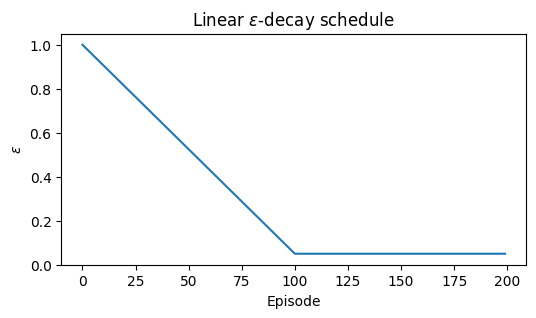

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def linear_schedule(t, eps_start=1.0, eps_end=0.05, decay_episodes=100):
    return max(eps_end, eps_start - (eps_start - eps_end) * t / decay_episodes)

# the schedule we will use everywhere: explore early, exploit once the network has learned
ts = np.arange(200)
plt.figure(figsize=(6, 3))
plt.plot(ts, [linear_schedule(t, decay_episodes=100) for t in ts])
plt.xlabel("Episode"); plt.ylabel(r"$\epsilon$")
plt.title(r"Linear $\epsilon$-decay schedule")
plt.ylim(0, 1.05)
plt.show()

## Sanity Check on FrozenLake

Before a continuous environment, let's confirm that swapping the Q-table for a small neural network is still able to solve a small grid navigation problem.

![frozen_lake](https://gymnasium.farama.org/_images/frozen_lake.gif)

Reminder: In FrozenLake the agent starts in the top-left cell and must reach the goal in the bottom-right without stepping into a hole. The agent knows its exact location and it can perform one of four actions to any adjacent cell.

### State representation

The state is represented as a number between 0 and 15. For a neural network, such discrete states are best represented as a one-hot vector.

In [6]:
def one_hot_state(s, n):
    x = torch.zeros(n, dtype=torch.float32)
    x[s] = 1.0
    return x

one_hot_state(1, 4)

tensor([0., 1., 0., 0.])

### Training DQN

The training algorithm is identical to Q-learning, but the Q-values are computed using our neural network.

**Note:** The TD-target is computed without triggering gradient tracking. This is important because we only want to update the weights according to the state-action pair for which the value is being updated. The target is meant to be a fixed reference value.

In [7]:
from gymnasium.spaces import Discrete
import numpy as np
import random
from tqdm.auto import tqdm

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

def eval_qnet(env, qnet, gamma, n_states, encode, seed):
    ret = 0
    discount = 1

    obs, _ = env.reset(seed=seed)
    # value estimate of the start state, max_a Q(s0, a)
    x0 = one_hot_state(obs, n_states) if encode else torch.from_numpy(obs)
    with torch.no_grad():
        max_q = float(qnet(x0).max().item())
    term = trun = False
    while not (term or trun):
        if encode:
            x = one_hot_state(obs, n_states)
        else:
            x = torch.from_numpy(obs)
        with torch.no_grad():
            a = int(qnet(x).argmax().item())
        obs, r, term, trun, _ = env.step(a)
        ret += r
        discount *= gamma

    return ret, max_q

def train_dqn_naive(env, n_episodes=1500, gamma=0.95, lr=5e-3, hidden_dim=32,
               eps_start=1.0, eps_end=0.05, eps_decay_episodes=800,
               eval_every=50, n_eval=1,  # deterministic, only 1 eval needed
               seed=0):
    # set seed for reproducibility
    set_seed(seed)

    # initialize environment
    if isinstance(env.observation_space, Discrete):
        n_states = env.observation_space.n
        encode = True
    else:
        n_states = env.observation_space.shape[0]
        encode = False
    n_actions = env.action_space.n

    # initialize qnet
    qnet = QNet(in_dim=n_states, n_actions=n_actions, hidden=hidden_dim)

    # initialize optimizer
    # this is used to update the qnet parameters after backpropagation
    optimizer = torch.optim.Adam(qnet.parameters(), lr=lr)

    eval_returns = []
    q_values = []
    for episode in tqdm(range(n_episodes), leave=False):
        obs, _ = env.reset(seed=seed + episode)
        
        # encode state to vector
        if encode:
            x = one_hot_state(obs, n_states)
        else:
            x = torch.from_numpy(obs)
        
        # get epsilon from schedule
        epsilon = linear_schedule(episode, eps_start, eps_end, eps_decay_episodes)

        term = trun = False
        while not (term or trun):

            # choose epsilon-greedy action
            q = qnet(x)
            if np.random.rand() < epsilon:
                a = np.random.randint(n_actions)
            else:
                a = int(q.argmax().item())

            # step environment
            next_obs, r, term, trun, _ = env.step(a)
            if encode:
                next_x = one_hot_state(next_obs, n_states)
            else:
                next_x = torch.from_numpy(next_obs)

            # if a terminal state is reached, the q-value is 0.
            # force 0 q value
            if term:
                next_q = 0.0
            else:
                # This is part of the TD-target. compute without gradient.
                with torch.no_grad():
                    next_q = qnet(next_x).max().item()

            target = torch.tensor(r + gamma * next_q, dtype=torch.float32)
            pred = q[a]
            loss = (pred - target).pow(2)

            # optimization step with backprop
            optimizer.zero_grad()  # zero all existing gradients
            loss.backward()  # backprop to compute gradients
            optimizer.step()  # update qnet parameters
            
            x = next_x

        # evaluate the current policy
        if episode % eval_every == 0:
            ret = 0
            max_q = 0
            for ev in range(n_eval):
                r, q = eval_qnet(env, qnet, gamma, n_states, encode,
                                seed=10_000 + seed + episode + ev)
                ret += r
                max_q += q
            eval_returns.append((episode, ret / n_eval))
            q_values.append((episode, max_q / n_eval))
    return eval_returns, q_values, qnet

### Run training

  0%|          | 0/1500 [00:00<?, ?it/s]

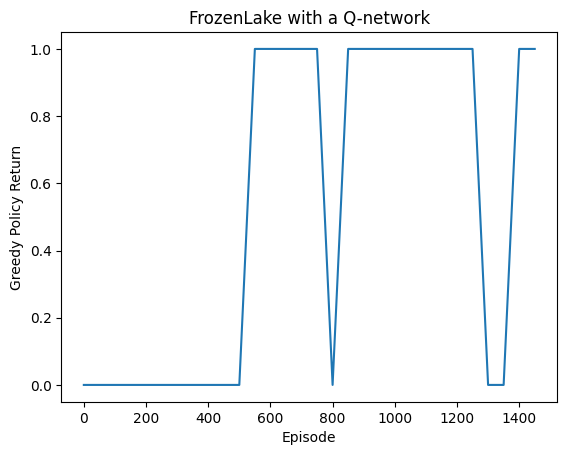

In [8]:
env = gym.make("FrozenLake-v1", is_slippery=False)
scores, _, _ = train_dqn_naive(env, seed=42)
episodes = [s[0] for s in scores]
rates = [s[1] for s in scores]

plt.plot(episodes, rates)
plt.xlabel("Episode")
plt.ylabel("Greedy Policy Return")
plt.title("FrozenLake with a Q-network")
plt.show()

The Q-network reaches a 100% success rate after roughly 600 episodes, though sometimes it suffers from a "forgetting" phenomenon.

_Question_: what aspects of the DQN algorithm might be causing the forgetting?

## DQN on a Continuous State Space (CartPole)

Back to CartPole, we now have a continuous state space. Each state is a vector of 4 continuous values for cart position and velocity, as well as pole angle and angular velocity. The table could not handle this, but a neural network function approximator can. The reward is dense, so this shouldn't take too long

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

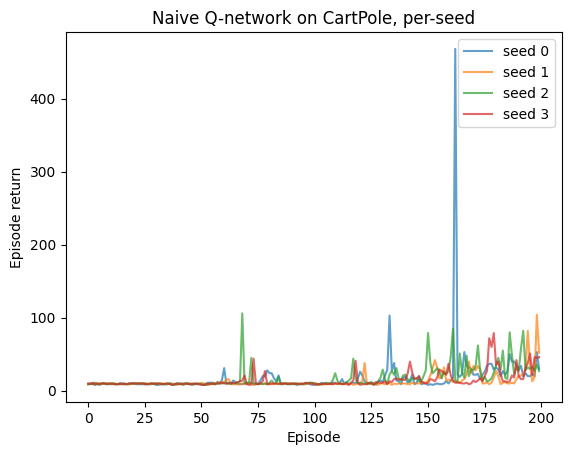

In [9]:
env = gym.make("CartPole-v1")

n_seeds = 4
naive_returns = []
for seed in tqdm(range(n_seeds)):
    rets, _, _ = train_dqn_naive(env, n_episodes=200, gamma=0.99, lr=1e-3, hidden_dim=64,
                      eps_start=0.1, eps_end=0.1,
                      eval_every=1, n_eval=1,
                      seed=seed)
    naive_returns.append(rets)

for i, rets in enumerate(naive_returns):
    plt.plot(*zip(*rets), alpha=0.7, label=f"seed {i}")
plt.xlabel("Episode")
plt.ylabel("Episode return")
plt.title("Naive Q-network on CartPole, per-seed")
plt.legend()
plt.show()

_Question_. Does the agent improve consistently? Are the curves stable across seeds?

What we are seeing is a manifestation of the **deadly triad**, the combination of three ingredients that together destabilizes value-based methods under function approximation.

1. **Bootstrapping**. The target depends on the current estimate $Q_\theta$, so the optimization moves a target it is trying to hit.
2. **Off-policy data**. The agent uses an $\epsilon$-greedy behavior policy to gather transitions but updates toward the greedy policy.
3. **Function approximation**. A change to $\theta$ affects predictions at many states, including those whose targets it is using.

With a table, the third ingredient is absent and Q-learning is stable. With a network, all three are present and the naive update can oscillate or diverge. We will solve these issues one by one.

## Replay Buffer

Consecutive transitions visited by the same trajectory are highly correlated. Gradient descent assumes (approximately) i.i.d. samples, which gives a noisy but unbiased gradient. Correlated samples violate this assumption and tend to push the network along the trajectory it just took, which interacts badly with bootstrapping.

The fix is to store transitions in a buffer $\mathcal{D}$, called the **replay buffer**, and train on uniform minibatches drawn from $\mathcal{D}$. The objective becomes
$$L(\theta) = \mathbb{E}_{(s, a, r, s') \sim \mathcal{D}} \left[ \left( r + \gamma \max_{a'} Q_\theta(s', a') - Q_\theta(s, a) \right)^2 \right].$$
The buffer mixes old and new transitions, which breaks the temporal correlation and reuses each sample many times.

In [10]:
from collections import deque
import random

class ReplayBuffer:
    def __init__(self, capacity):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s_next, done):
        self.buf.append((s, a, r, s_next, float(done)))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s_next, d = zip(*batch)
        return (
            torch.from_numpy(np.asarray(s, dtype=np.float32)),
            torch.tensor(a, dtype=torch.long),
            torch.tensor(r, dtype=torch.float32),
            torch.from_numpy(np.asarray(s_next, dtype=np.float32)),
            torch.tensor(d, dtype=torch.float32),
        )

    def __len__(self):
        return len(self.buf)

### Training with a buffer

We change two things from our previous algorithm:
1. After each step, add the new experience to the buffer and train the model on all collected experiences.
2. Do a **warmup** where we collect samples before training to populate the buffer.

In [11]:
def train_dqn_with_buffer(env, n_episodes=300, gamma=0.99, lr=1e-3, hidden_dim=64,
                           eps_start=0.1, eps_end=0.1, eps_decay_episodes=800,
                           eval_every=1, n_eval=1,
                           buffer_size=1000, warmup=200, train_every=1, batch_size=64,
                           seed=0):
    set_seed(seed)
    if isinstance(env.observation_space, Discrete):
        n_states = env.observation_space.n
        encode = True
    else:
        n_states = env.observation_space.shape[0]
        encode = False
    n_actions = env.action_space.n
    qnet = QNet(in_dim=n_states, n_actions=n_actions, hidden=hidden_dim)
    optimizer = torch.optim.Adam(qnet.parameters(), lr=lr)

    # initialize replay buffer
    buffer = ReplayBuffer(buffer_size)

    eval_returns = []
    q_values = []
    for episode in tqdm(range(n_episodes), leave=False):
        obs, _ = env.reset(seed=seed + episode)
        if encode:
            x = one_hot_state(obs, n_states)
        else:
            x = torch.from_numpy(obs)
        epsilon = linear_schedule(episode, eps_start, eps_end, eps_decay_episodes)
        term = trun = False
        while not (term or trun):
            if np.random.rand() < epsilon:
                a = np.random.randint(n_actions)
            else:
                with torch.no_grad():
                    q = qnet(x)  # only collecting in buffer. no grad required
                a = int(q.argmax().item())
            next_obs, r, term, trun, _ = env.step(a)
            if encode:
                next_x = one_hot_state(next_obs, n_states)
            else:
                next_x = torch.from_numpy(next_obs)

            # append new experience to the buffer
            buffer.push(x, a, r, next_x, term)

            x = next_x

            # update according to all buffer estimates
            if len(buffer) >= max(warmup, batch_size) and len(buffer) % train_every == 0:
                s, ac, rw, s_next, t = buffer.sample(batch_size)

                with torch.no_grad():
                    target = rw + gamma * qnet(s_next).max(dim=1).values * (1 - t)
                pred = qnet(s).gather(1, ac.unsqueeze(1)).squeeze(1)
                loss = (pred - target).pow(2).mean()
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if episode % eval_every == 0:
            ret = 0
            max_q = 0
            for ev in range(n_eval):
                r, q = eval_qnet(env, qnet, gamma, n_states, encode,
                                seed=10_000 + seed + episode + ev)
                ret += r
                max_q += q
            eval_returns.append((episode, ret / n_eval))
            q_values.append((episode, max_q / n_eval))
    return eval_returns, q_values, qnet

### Run Training

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

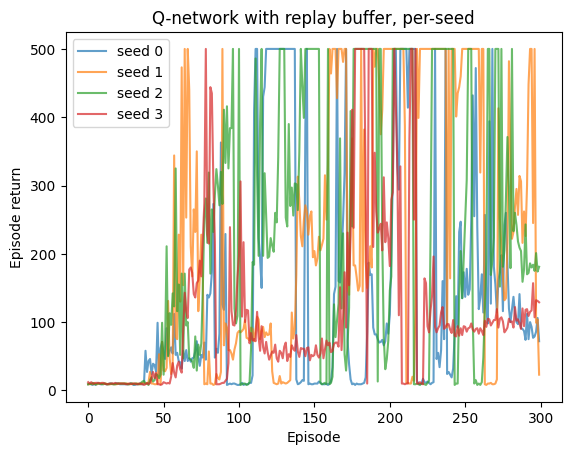

In [12]:
buffer_returns = []
for seed in tqdm(range(n_seeds)):
    rets, _, _ = train_dqn_with_buffer(env, seed=seed)
    buffer_returns.append(rets)

for i, rets in enumerate(buffer_returns):
    plt.plot(*zip(*rets), alpha=0.7, label=f"seed {i}")
plt.xlabel("Episode")
plt.ylabel("Episode return")
plt.title("Q-network with replay buffer, per-seed")
plt.legend()
plt.show()

Training has improved substantially. We are able to achieve the maximum reward of 500. However, training is still very unstable.

### Choosing the Buffer Size

So far we picked $10{,}000$ as the buffer capacity, which was arbitrary. Two regimes are worth thinking about.

- **Buffer too small.** With capacity barely above the batch size, we resample almost the data we just collected. Old transitions are evicted before they are reused, so the correlated-sample problem returns and learning sits near the random baseline.
- **Buffer too large.** The buffer keeps transitions from long-dead policies. Their distribution no longer matches the current behavior, so most gradient steps come from stale targets and learning lags.

### Buffer Size Sweep

In [13]:
from pathlib import Path
import pickle

cache_dir = Path("cache")
cache_dir.mkdir(exist_ok=True)
sweep_path = cache_dir / "buffer_sweep.pkl"

buffer_sizes = [200, 1_000, 10_000, 50_000]
sweep_seeds = list(range(3))

if sweep_path.exists():
    with open(sweep_path, "rb") as f:
        sweep_results = pickle.load(f)
    print(f"Loaded cached sweep from {sweep_path}")
else:
    sweep_results = {}
    for cap in tqdm(buffer_sizes, desc="buffer size"):
        sweep_results[cap] = [train_dqn_with_buffer(env, buffer_size=cap, seed=s)[0]
                              for s in tqdm(sweep_seeds, desc="seed", leave=False)]
    with open(sweep_path, "wb") as f:
        pickle.dump(sweep_results, f)
    print(f"Saved sweep to {sweep_path}")

Loaded cached sweep from cache/buffer_sweep.pkl


### Visualize Buffer Choices

In [14]:
from ipywidgets import interact

def rolling_mean(x, window=20):
    x = np.asarray(x, dtype=float)
    if window <= 1:
        return x
    out = np.empty_like(x)
    for i in range(len(x)):
        lo = max(0, i - window + 1)
        out[i] = x[lo:i + 1].mean()
    return out

@interact(buffer_size=buffer_sizes)
def plot_buffer_sweep(buffer_size=buffer_sizes[1]):
    runs = sweep_results[buffer_size]
    episodes = [ep for ep, _ in runs[0]]
    returns = np.asarray([[ret for _, ret in run] for run in runs])
    smoothed = np.stack([rolling_mean(r) for r in returns])
    mean_curve = smoothed.mean(axis=0)
    last_50 = returns[:, -50:].mean()

    plt.figure(figsize=(8, 4))
    for r in smoothed:
        plt.plot(episodes, r, alpha=0.35, color="C0")
    plt.plot(episodes, mean_curve, color="C0", linewidth=2.5,
             label=f"mean across seeds (last 50 episodes = {last_50:.0f})")
    plt.xlabel("Episode")
    plt.ylabel("Episode return (rolling mean, window=20)")
    plt.title(f"buffer size = {buffer_size}")
    plt.ylim(-10, 520)
    plt.legend(loc="upper left")
    plt.show()

interactive(children=(Dropdown(description='buffer_size', index=1, options=(200, 1000, 10000, 50000), value=10…

As you we can see, there is a "sweet spot" buffer size.

The takeaway is qualitative. The buffer must be **large enough to break temporal correlation but small enough to track the current policy**. The exact sweet spot depends on the environment, the policy update frequency, and the rest of the training setup. For Atari-scale problems in production DQN, $10^5$ to $10^6$ are typical.

## 4. Target Network

The buffer-size sweep ended on a frustrating note. Even at a well-chosen buffer size, the learning curves shoot up and then collapse. A crucial ingredient of the deadly triad is still unaddressed.

The bootstrap target $r + \gamma \max_{a'} Q_\theta(s', a')$ depends on the same parameters $\theta$ we are updating. Each gradient step shifts both the prediction $Q_\theta(s, a)$ and the target it is being compared to. The optimizer is chasing a target that moves with every step, which is exactly the configuration where bootstrapping plus function approximation tends to spiral.

The fix introduced by Mnih et al. is the **target network**. We keep a frozen copy $Q_{\bar\theta}$ of the Q-network for computing targets, and copy $\bar\theta \leftarrow \theta$ every $N$ gradient steps, syncing the two models. The loss becomes
$$L(\theta) = \mathbb{E}_{(s, a, r, s') \sim \mathcal{D}} \left[ \left( r + \gamma \max_{a'} Q_{\bar\theta}(s', a') - Q_\theta(s, a) \right)^2 \right].$$

Between syncs the target is frozen, so gradient descent optimizes a stationary objective for $N$ steps at a time. After each sync, the new fixed target reflects the latest progress, and the cycle repeats. We pay a small cost in fitting accuracy (we are fitting toward yesterday's network for a while) and buy a large amount of stability.

### Training with a target network

We augment our replay buffer DQN implementaiton with an additional network used for computing the maximum value at the next state. This is only used when training on the buffer

In [15]:
def train_dqn_full(env, n_episodes=300, gamma=0.99, lr=1e-3, hidden_dim=64,
                               eps_start=0.1, eps_end=0.1, eps_decay_episodes=800,
                               eval_every=1, n_eval=1,
                               buffer_size=1000, warmup=200, train_every=1, batch_size=64,
                               target_sync_freq=200,
                               seed=0):
    set_seed(seed)
    if isinstance(env.observation_space, Discrete):
        n_states = env.observation_space.n
        encode = True
    else:
        n_states = env.observation_space.shape[0]
        encode = False
    n_actions = env.action_space.n
    qnet = QNet(in_dim=n_states, n_actions=n_actions, hidden=hidden_dim)
    optimizer = torch.optim.Adam(qnet.parameters(), lr=lr)
    buffer = ReplayBuffer(buffer_size)

    # initialize additional qnet with identical weights
    qnet_target = QNet(in_dim=n_states, n_actions=n_actions, hidden=hidden_dim)
    qnet_target.load_state_dict(qnet.state_dict())

    # maintain a counter of gradient descent steps for sync frequency
    grad_steps = 0

    eval_returns = []
    q_values = []
    for episode in tqdm(range(n_episodes), leave=False):
        obs, _ = env.reset(seed=seed + episode)
        if encode:
            x = one_hot_state(obs, n_states)
        else:
            x = torch.from_numpy(obs)
        epsilon = linear_schedule(episode, eps_start, eps_end, eps_decay_episodes)
        term = trun = False
        while not (term or trun):
            if np.random.rand() < epsilon:
                a = np.random.randint(n_actions)
            else:
                with torch.no_grad():
                    q = qnet(x)  # only collecting in buffer. no grad required
                a = int(q.argmax().item())
            next_obs, r, term, trun, _ = env.step(a)
            if encode:
                next_x = one_hot_state(next_obs, n_states)
            else:
                next_x = torch.from_numpy(next_obs)
            buffer.push(x, a, r, next_x, term)
            x = next_x
            if len(buffer) >= max(warmup, batch_size) and len(buffer) % train_every == 0:
                s, ac, rw, s_next, t = buffer.sample(batch_size)

                # use target network instead of the trained network
                with torch.no_grad():                
                    target = rw + gamma * qnet_target(s_next).max(dim=1).values * (1 - t)
    
                pred = qnet(s).gather(1, ac.unsqueeze(1)).squeeze(1)
                loss = (pred - target).pow(2).mean()
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                # update the target network if required
                grad_steps += 1
                if grad_steps % target_sync_freq == 0:
                    qnet_target.load_state_dict(qnet.state_dict())

        if episode % eval_every == 0:
            ret = 0
            max_q = 0
            for ev in range(n_eval):
                r, q = eval_qnet(env, qnet, gamma, n_states, encode,
                                seed=10_000 + seed + episode + ev)
                ret += r
                max_q += q
            eval_returns.append((episode, ret / n_eval))
            q_values.append((episode, max_q / n_eval))
    return eval_returns, q_values, qnet

### Running Training

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

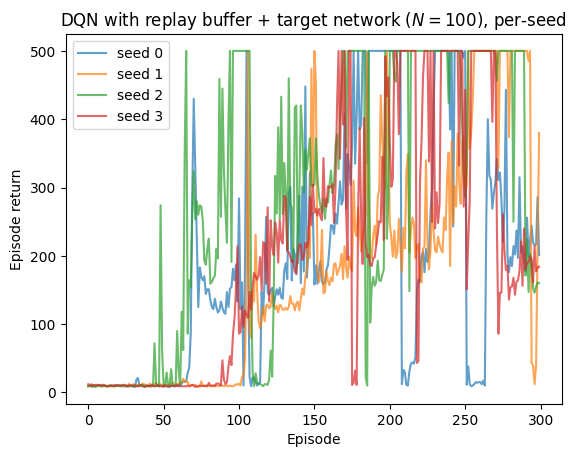

In [16]:
dqn_returns = []
for seed in tqdm(range(n_seeds)):
    rets, _, _ = train_dqn_full(env, seed=seed, target_sync_freq=100, eval_every=1, n_eval=1)
    dqn_returns.append(rets)

for i, rets in enumerate(dqn_returns):
    plt.plot(*zip(*rets), alpha=0.7, label=f"seed {i}")
plt.xlabel("Episode")
plt.ylabel("Episode return")
plt.title("DQN with replay buffer + target network ($N = 100$), per-seed")
plt.legend()
plt.show()

The collapses are gone. Three of four seeds reach the 500 ceiling within 200 episodes, and the fourth is well above the buffer-only collapse level. Where the buffer-only curves rose and then crashed back to baseline, these curves climb broadly upward, with the worst case being a slower but sustained ascent rather than a rise-and-fall.

To make the effect of the target network explicit, here are the smoothed mean returns from both configurations on a single axis.

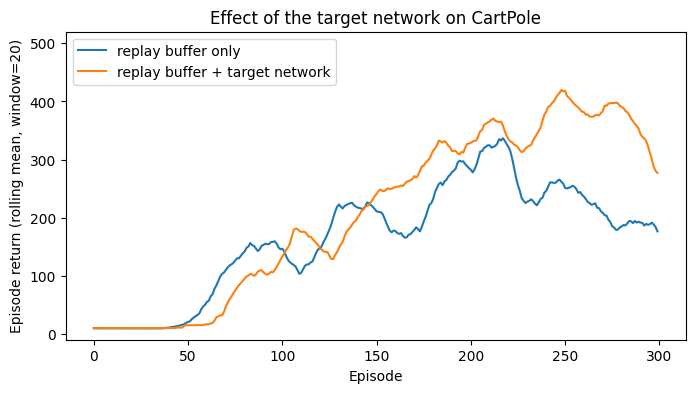

In [17]:
buffer_episodes = [ep for ep, _ in buffer_returns[0]]
buffer_rets = [[r for _, r in ret] for ret in buffer_returns]
dqn_episodes = [ep for ep, _ in dqn_returns[0]]
dqn_rets = [[r for _, r in ret] for ret in dqn_returns]

buffer_smooth = np.stack([rolling_mean(r) for r in buffer_rets]).mean(axis=0)
dqn_smooth = np.stack([rolling_mean(r) for r in dqn_rets]).mean(axis=0)

plt.figure(figsize=(8, 4))
plt.plot(buffer_episodes, buffer_smooth, label="replay buffer only", color="C0")
plt.plot(dqn_episodes, dqn_smooth, label="replay buffer + target network", color="C1")
plt.xlabel("Episode")
plt.ylabel("Episode return (rolling mean, window=20)")
plt.title("Effect of the target network on CartPole")
plt.ylim(-10, 520)
plt.legend(loc="upper left")
plt.show()

The two curves illustrate the value of the target network cleanly. The buffer-only configuration ramps faster initially and peaks around episode 130, but the peak is illusory. The moving-target instability bites and the mean return collapses back to roughly 100 by the end of training. The target-network configuration ramps more slowly, never overshoots, and is still trending up at episode 200, ending well above the buffer-only configuration. The target net gives us both stability and, given enough time, higher returns.

### Target-Sync Frequency Sweep

Like the buffer size, the sync frequency $N$ is a hyperparameter that requires tuning. Let's sweep several values as we did before.

In [18]:
target_sweep_path = cache_dir / "target_sync_sweep.pkl"
sync_freqs = [1, 10, 100, 500, 2000]

if target_sweep_path.exists():
    with open(target_sweep_path, "rb") as f:
        sync_results = pickle.load(f)
    print(f"Loaded cached sweep from {target_sweep_path}")
else:
    sync_results = {}
    for freq in tqdm(sync_freqs, desc="sync freq"):
        sync_results[freq] = [train_dqn_full(env, target_sync_freq=freq, seed=s)[0]
                              for s in sweep_seeds]
    with open(target_sweep_path, "wb") as f:
        pickle.dump(sync_results, f)
    print(f"Saved sweep to {target_sweep_path}")

Loaded cached sweep from cache/target_sync_sweep.pkl


### Visualize Sync Frequency Choice

In [19]:
@interact(sync_freq=sync_freqs)
def plot_target_sweep(sync_freq=sync_freqs[2]):
    runs = sync_results[sync_freq]
    episodes = [ep for ep, _ in runs[0]]
    returns = np.asarray([[ret for _, ret in run] for run in runs])
    smoothed = np.stack([rolling_mean(r) for r in returns])
    mean_curve = smoothed.mean(axis=0)
    last_50 = returns[:, -50:].mean()

    plt.figure(figsize=(8, 4))
    for r in smoothed:
        plt.plot(r, alpha=0.35, color="C1")
    plt.plot(mean_curve, color="C1", linewidth=2.5,
             label=f"mean across seeds (last 50 episodes = {last_50:.0f})")
    plt.xlabel("Episode")
    plt.ylabel("Episode return (rolling mean, window=20)")
    plt.title(f"sync every {sync_freq} gradient steps")
    plt.ylim(-10, 520)
    plt.legend(loc="upper left")
    plt.show()

interactive(children=(Dropdown(description='sync_freq', index=2, options=(1, 10, 100, 500, 2000), value=100), …

- **Sync too slow.** The frozen target lags far behind the current network. The gradient is well-conditioned but pulls toward stale values, and the agent's improvements take a long time to be reflected in the targets it fits.
- **Sync too fast.** Between syncs the target barely freezes, so the bootstrap target moves nearly as fast as the network. We slide back toward the moving-target instability from section 3.

## Summary of DQN Implementation

**Algorithm. Deep Q-Network (DQN)**

1. Initialize Q-network parameters $\theta$ at random
2. Initialize target network $\bar\theta \leftarrow \theta$
3. Initialize replay buffer $\mathcal{D}$ with capacity $C$
4. For episode $= 1, \ldots, M$
    1. Reset the environment, observe initial state $s$
    2. Set $\epsilon$ from the linear schedule for this episode
    3. Repeat until episode ends
        1. With probability $\epsilon$ choose a random action, else $a = \arg\max_{a'} Q_\theta(s, a')$
        2. Take action $a$, observe reward $r$ and next state $s'$
        3. Store $(s, a, r, s', \mathrm{done})$ in $\mathcal{D}$
        4. Sample minibatch of $B$ transitions from $\mathcal{D}$
        5. Compute target $y = r + \gamma (1 - \mathrm{done}) \max_{a'} Q_{\bar\theta}(s', a')$
        6. Update $\theta$ by gradient descent on $\bigl(Q_\theta(s, a) - y\bigr)^2$
        7. Every $N$ gradient steps, sync $\bar\theta \leftarrow \theta$
        8. $s \leftarrow s'$

The free hyperparameters are the discount $\gamma$, the learning rate, the replay capacity $C$, the batch size $B$, the target-sync interval $N$, and the $\epsilon$ schedule.

## Overestimation Bias

DQN forms its target with a $\max$ over the next state's action values, $y = r + \gamma \max_{a'} Q_{\bar\theta}(s', a')$. Because the Q-values are *noisy estimates*, that $\max$ is biased **upward**, meaning that on average, it reports more than the true best value. Neither the replay buffer nor the target network removes this bias.

### Why this happens

Suppose every action at a state shares the same true value $v$, and our estimates are $Q(s, a) = v + \varepsilon_a$ with independent zero-mean noise. The target uses
$$\max_a Q(s, a) = v + \max_a \varepsilon_a,$$
and the maximum of several zero-mean noises is **positive** on average, so the target overshoots $v$. With $N$ actions the overshoot grows like $\sqrt{2 \ln N}$ (more actions $\Longrightarrow$ more bias).

A single overshoot would be harmless. The danger is the **bootstrapping**: an overestimated state feeds its inflated value into the targets of the states that lead to it, which inflates the bias further. Within a training loop, the bias compounds on itself and persists.

### The Fork Environment

We use a tiny environment adapted from the classic maximization-bias example of Sutton and Barto (Example 6.7 in [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html)), shaped so the bias has somewhere to do damage.

![fork](images/fork.png)

- **State A (start)** is a fork with 32 actions. Action `0` is **right**: it ends the episode immediately with reward 0. Any other action is **left**: it moves to state B with reward 0.
- **State B** is a self-loop. Each step pays a reward $\sim \mathcal{N}(-0.1, 1)$ and stays in B, for up to 50 steps.
- **Observation**: a one-hot of the current state, a 2-vector.

The outcomes are unambiguous. Going **right** returns 0. Going **left** sends you into B, where each of the up to 50 steps costs $0.1$ on average, for a total return of about $50 \times (-0.1) = -5$. So the optimal action at A is **right**. But B has 32 noisy actions and loops on itself, exactly the recipe for overestimation, so we expect a vanilla DQN to overvalue **left** and walk into the losing branch.

### Fork Environment Implementation

In [20]:
from gymnasium import spaces


class ForkEnv(gym.Env):
    """State A: action 0 = right -> terminal (reward 0). Any other action = left
    -> state B. State B: 32-action self-loop with reward ~ N(-0.1, 1) for 50
    steps. The optimal action at A is right (going left returns about -5)."""

    def __init__(self, n_actions=32, b_mean=-0.1, b_sigma=1.0, b_steps=50):
        super().__init__()
        self.b_mean = b_mean
        self.b_sigma = b_sigma
        self.b_steps = b_steps
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(2,), dtype=np.float32)
        self.action_space = spaces.Discrete(n_actions)
        self.state = 0
        self.t = 0

    def _obs(self):
        x = np.zeros(2, dtype=np.float32)
        x[self.state] = 1.0
        return x

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = 0
        self.t = 0
        return self._obs(), {}

    def step(self, action):
        if self.state == 0:
            if action == 0:                       # right -> terminal
                return self._obs(), 0.0, True, False, {}
            self.state = 1                         # left -> B
            return self._obs(), 0.0, False, False, {}
        self.t += 1
        r = float(self.np_random.normal(self.b_mean, self.b_sigma))
        truncated = self.t >= self.b_steps
        return self._obs(), r, False, truncated, {}

### Training a Vanilla DQN

We train our DQN (`train_dqn_full`) on the fork for several seeds and track two things at each evaluation: the greedy **evaluation return** (left panel below) and the network's **value estimate of the start state**, $\max_a Q(A, a)$ (right panel). A converged greedy policy can only return $0$ (go right, optimal) or about $-5$ (go left), and the true start-state value is $V^*(A) = 0$.

In [21]:
fork_seeds = list(range(8))

fork_dqn_path = cache_dir / "fork_dqn.pkl"
if fork_dqn_path.exists():
    with open(fork_dqn_path, "rb") as f:
        fork_dqn = pickle.load(f)
    print(f"Loaded cached results from {fork_dqn_path}")
else:
    fork_dqn = [train_dqn_full(ForkEnv(), seed=s) for s in tqdm(fork_seeds)]
    with open(fork_dqn_path, "wb") as f:
        pickle.dump(fork_dqn, f)
    print(f"Saved results to {fork_dqn_path}")

Loaded cached results from cache/fork_dqn.pkl


### Visualize the Overestimation

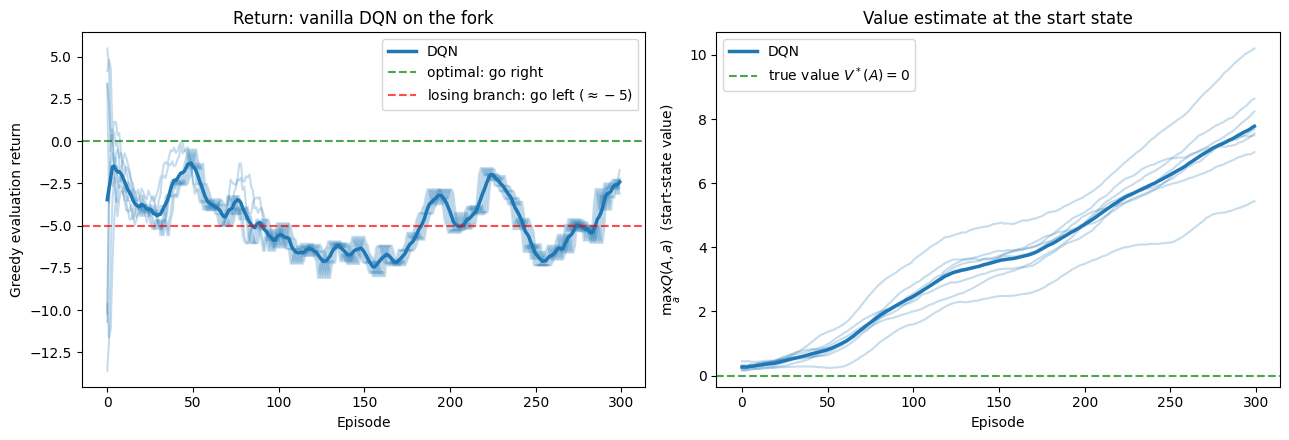

In [22]:
def fork_curves(runs):
    episodes = [ep for ep, _ in runs[0][0]]
    returns = np.asarray([[ret for _, ret in run[0]] for run in runs])
    qvals = np.asarray([[q for _, q in run[1]] for run in runs])
    return episodes, returns, qvals

episodes, dqn_ret, dqn_q = fork_curves(fork_dqn)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for r in dqn_ret:
    axes[0].plot(episodes, rolling_mean(r, 20), color="C0", alpha=0.25)
axes[0].plot(episodes, rolling_mean(dqn_ret.mean(axis=0), 20), color="C0", linewidth=2.5, label="DQN")
axes[0].axhline(0.0, color="g", linestyle="--", alpha=0.7, label="optimal: go right")
axes[0].axhline(-5.0, color="r", linestyle="--", alpha=0.7, label="losing branch: go left ($\\approx -5$)")
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Greedy evaluation return")
axes[0].set_title("Return: vanilla DQN on the fork")
axes[0].legend()

for q in dqn_q:
    axes[1].plot(episodes, rolling_mean(q, 20), color="C0", alpha=0.25)
axes[1].plot(episodes, rolling_mean(dqn_q.mean(axis=0), 20), color="C0", linewidth=2.5, label="DQN")
axes[1].axhline(0.0, color="g", linestyle="--", alpha=0.7, label="true value $V^*(A) = 0$")
axes[1].set_xlabel("Episode"); axes[1].set_ylabel(r"$\max_a Q(A, a)$  (start-state value)")
axes[1].set_title("Value estimate at the start state")
axes[1].legend()
plt.tight_layout(); plt.show()

Both panels tell the same story. On the **left**, the greedy return stays well below zero, down near the losing-branch line: the DQN has learned to take **left**. On the **right**, we see why, its value estimate for the start state climbs far above the true value of $0$. Overestimation inflated the 32-action loop above the safe exit, and the greedy policy followed the inflated values straight into it.

### The Fix: Double DQN

The bias comes from using the **same** network to both *select* and *evaluate* the best next action inside the $\max$. **Double DQN** ([van Hasselt, Guez, and Silver, 2016](https://arxiv.org/abs/1509.06461)) decouples the two roles: the online network picks the next action, the target network scores it,
$$y = r + \gamma\, Q_{\bar\theta}\!\left(s',\; \arg\max_{a'} Q_\theta(s', a')\right).$$
Selection and evaluation now draw on independent estimates, so their noise no longer conspires to push the target up. It is a one-line change to the target computation in `train_dqn_full`.

In [23]:
def train_double_dqn(env, n_episodes=300, gamma=0.99, lr=1e-3, hidden_dim=64,
                     eps_start=0.1, eps_end=0.1, eps_decay_episodes=800,
                     eval_every=1, n_eval=1,
                     buffer_size=1000, warmup=200, train_every=1, batch_size=64,
                     target_sync_freq=200,
                     seed=0):
    set_seed(seed)
    if isinstance(env.observation_space, Discrete):
        n_states = env.observation_space.n
        encode = True
    else:
        n_states = env.observation_space.shape[0]
        encode = False
    n_actions = env.action_space.n
    qnet = QNet(in_dim=n_states, n_actions=n_actions, hidden=hidden_dim)
    optimizer = torch.optim.Adam(qnet.parameters(), lr=lr)
    buffer = ReplayBuffer(buffer_size)
    qnet_target = QNet(in_dim=n_states, n_actions=n_actions, hidden=hidden_dim)
    qnet_target.load_state_dict(qnet.state_dict())
    grad_steps = 0

    eval_returns = []
    q_values = []
    for episode in tqdm(range(n_episodes), leave=False):
        obs, _ = env.reset(seed=seed + episode)
        if encode:
            x = one_hot_state(obs, n_states)
        else:
            x = torch.from_numpy(obs)
        epsilon = linear_schedule(episode, eps_start, eps_end, eps_decay_episodes)
        term = trun = False
        while not (term or trun):
            if np.random.rand() < epsilon:
                a = np.random.randint(n_actions)
            else:
                with torch.no_grad():
                    q = qnet(x)
                a = int(q.argmax().item())
            next_obs, r, term, trun, _ = env.step(a)
            if encode:
                next_x = one_hot_state(next_obs, n_states)
            else:
                next_x = torch.from_numpy(next_obs)
            buffer.push(x, a, r, next_x, term)
            x = next_x
            if len(buffer) >= max(warmup, batch_size) and len(buffer) % train_every == 0:
                s, ac, rw, s_next, t = buffer.sample(batch_size)

                # double DQN: the online net picks the next action, the target net scores it
                with torch.no_grad():
                    next_actions = qnet(s_next).argmax(dim=1)
                    next_q = qnet_target(s_next).gather(1, next_actions.unsqueeze(1)).squeeze(1)
                    target = rw + gamma * next_q * (1 - t)

                pred = qnet(s).gather(1, ac.unsqueeze(1)).squeeze(1)
                loss = (pred - target).pow(2).mean()
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                grad_steps += 1
                if grad_steps % target_sync_freq == 0:
                    qnet_target.load_state_dict(qnet.state_dict())

        if episode % eval_every == 0:
            ret = 0
            max_q = 0
            for ev in range(n_eval):
                r, q = eval_qnet(env, qnet, gamma, n_states, encode,
                                seed=10_000 + seed + episode + ev)
                ret += r
                max_q += q
            eval_returns.append((episode, ret / n_eval))
            q_values.append((episode, max_q / n_eval))
    return eval_returns, q_values, qnet

### Running Double DQN

In [24]:
fork_double_path = cache_dir / "fork_double.pkl"
if fork_double_path.exists():
    with open(fork_double_path, "rb") as f:
        fork_double = pickle.load(f)
    print(f"Loaded cached results from {fork_double_path}")
else:
    fork_double = [train_double_dqn(ForkEnv(), seed=s) for s in tqdm(fork_seeds)]
    with open(fork_double_path, "wb") as f:
        pickle.dump(fork_double, f)
    print(f"Saved results to {fork_double_path}")

Loaded cached results from cache/fork_double.pkl


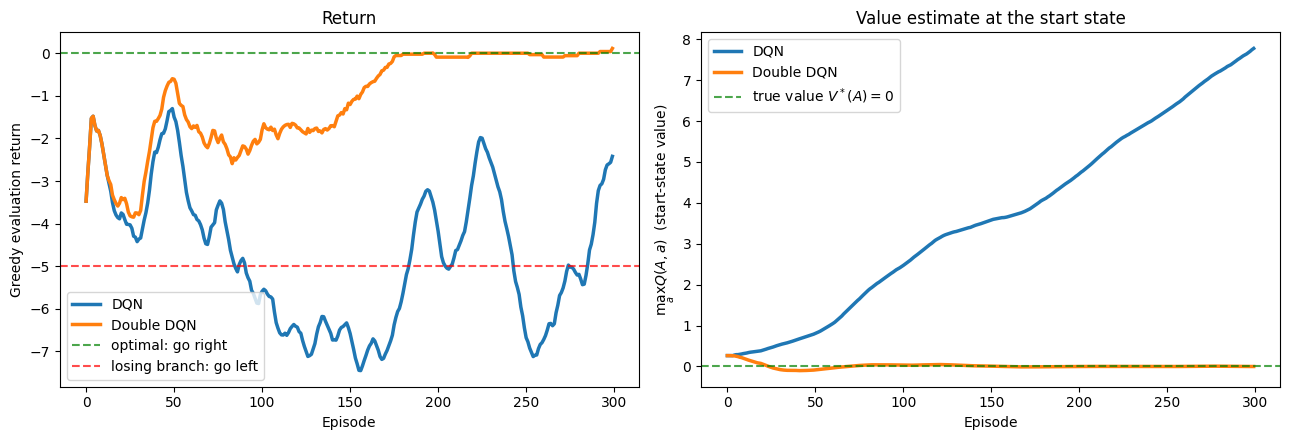

In [25]:
_, double_ret, double_q = fork_curves(fork_double)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(episodes, rolling_mean(dqn_ret.mean(axis=0), 20), color="C0", linewidth=2.5, label="DQN")
axes[0].plot(episodes, rolling_mean(double_ret.mean(axis=0), 20), color="C1", linewidth=2.5, label="Double DQN")
axes[0].axhline(0.0, color="g", linestyle="--", alpha=0.7, label="optimal: go right")
axes[0].axhline(-5.0, color="r", linestyle="--", alpha=0.7, label="losing branch: go left")
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Greedy evaluation return")
axes[0].set_title("Return")
axes[0].legend()

axes[1].plot(episodes, rolling_mean(dqn_q.mean(axis=0), 20), color="C0", linewidth=2.5, label="DQN")
axes[1].plot(episodes, rolling_mean(double_q.mean(axis=0), 20), color="C1", linewidth=2.5, label="Double DQN")
axes[1].axhline(0.0, color="g", linestyle="--", alpha=0.7, label="true value $V^*(A) = 0$")
axes[1].set_xlabel("Episode"); axes[1].set_ylabel(r"$\max_a Q(A, a)$  (start-state value)")
axes[1].set_title("Value estimate at the start state")
axes[1].legend()
plt.tight_layout(); plt.show()

The decision flips. On the **left**, Double DQN's greedy return sits on the optimal line at $0$: it values the safe exit above the noisy loop and takes **right**. On the **right**, its start-state value estimate stays pinned near the true value of $0$, while the vanilla DQN's keeps climbing. Same network, same compute, same data, only the target rule differs.

## Scaling Up (Lunar Lander)

We now scale DQN to LunarLander, a much harder continuous-state environment, and use it to settle two questions: does the overestimation bias from the previous section actually appear here, and how does our learned DQN compare against the planner from the previous lecture, MCTS, on the same problem?

![lunarlander](https://gymnasium.farama.org/_images/lunar_lander.gif)

### Environment Details

In [26]:
env = gym.make("LunarLander-v3")
print("Observation space", env.observation_space)
print("Action space     ", env.action_space)

Observation space Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space      Discrete(4)


**LunarLander-v3.** Land a small craft on a pad between two flags using three thrusters.

- **Observation**: 8 continuous numbers, the $x, y$ position, the $x, y$ velocity, the angle and angular velocity, and two binary leg-contact flags.
- **Actions**: 4 discrete, do nothing, fire left thruster, fire main thruster, fire right thruster.
- **Dynamics**: Box2D rigid-body physics with gravity; deterministic given a seed.
- **Reward**: shaped, the agent pays for fuel and for crashing and receives a large bonus for a soft landing on the pad.

_Question_: should we expect high overestimation bias?

### Reminder: Planning with MCTS

Recall MCTS from the previous lecture: with only a simulator and no training, it plans at decision time by building a search tree and rolling out from the leaves. Let's run it on LunarLander using uniform random rollouts.

In [27]:
import random
from gymcts.gymcts_agent import GymctsAgent
from gymcts.logger import log
from utils.lunar_lander_mcts_wrapper import LunarLanderMCTSWrapper
import mediapy as media

log.disabled = True

random.seed(0)
sim = gym.make("LunarLander-v3")
sim = LunarLanderMCTSWrapper(sim)
sim.reset(seed=0)
mcts_agent = GymctsAgent(env=sim, clear_mcts_tree_after_step=False,
                         number_of_simulations_per_step=50)
mcts_actions = mcts_agent.solve()

render_env = gym.make("LunarLander-v3", render_mode="rgb_array")
render_env.reset(seed=0)
frames = [render_env.render()]
mcts_total = 0.0
for a in mcts_actions:
    _, r, term, trun, _ = render_env.step(a)
    mcts_total += r
    frames.append(render_env.render())
    if term or trun:
        break
print(f"MCTS episode reward: {mcts_total:.0f}")
media.show_video(frames, fps=30)

MCTS episode reward: 41


This browser does not support the video tag.


MCTS does something, but it tends to crash or drift rather than land. Recall that we needed to play with the exploration constant to see an OK landing. A clean landing simulation is rare so the values backed up the tree carry little signal, and a modest simulation budget cannot search the long horizon densely enough.

### Training DQN and Double DQN

We train both algorithms with the **same network and the same number of episodes** (400, three seeds), so any difference is the algorithm and not the budget. Notice that MCTS gets 200 rollouts per step while our DQNs get 400 rollouts total!

In [28]:
lunar_cache_path = cache_dir / "lunar_dqn_vs_double.pkl"
lunar_kwargs = dict(
    n_episodes=400,
    gamma=0.99,
    lr=5e-4,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_episodes=300,
    buffer_size=50_000,
    batch_size=64,
    warmup=1000,
    target_sync_freq=500,
    hidden_dim=128,
)

if lunar_cache_path.exists():
    with open(lunar_cache_path, "rb") as f:
        lunar_results = pickle.load(f)
    print(f"Loaded cached results from {lunar_cache_path}")
else:
    lunar_results = {"DQN": [], "Double DQN": []}
    for s in tqdm(sweep_seeds, desc="DQN seeds"):
        er, qv, _ = train_dqn_full(gym.make("LunarLander-v3"), seed=s, **lunar_kwargs)
        lunar_results["DQN"].append(([r for _, r in er], [q for _, q in qv]))
    for s in tqdm(sweep_seeds, desc="Double DQN seeds"):
        er, qv, _ = train_double_dqn(gym.make("LunarLander-v3"), seed=s, **lunar_kwargs)
        lunar_results["Double DQN"].append(([r for _, r in er], [q for _, q in qv]))
    with open(lunar_cache_path, "wb") as f:
        pickle.dump(lunar_results, f)
    print(f"Saved results to {lunar_cache_path}")

Loaded cached results from cache/lunar_dqn_vs_double.pkl


### Visualizing DQN vs Double DQN

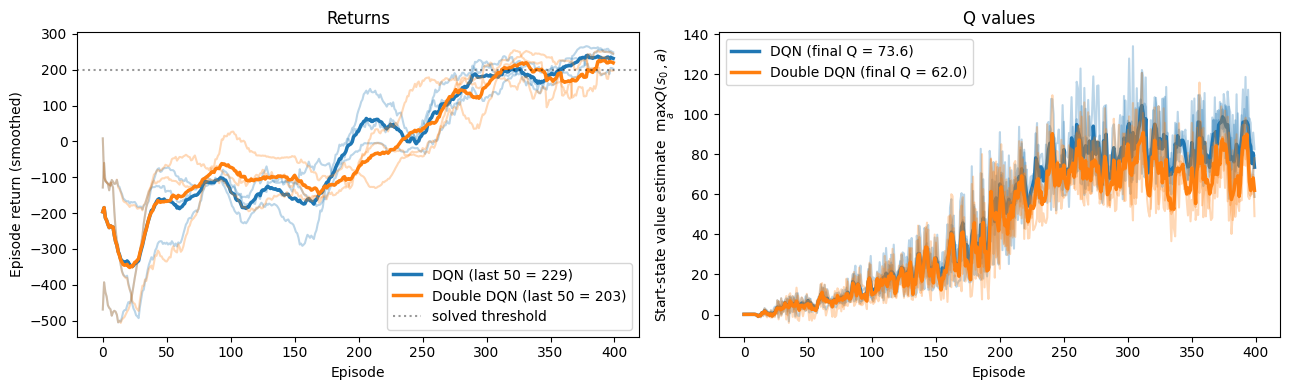

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, color in [("DQN", "C0"), ("Double DQN", "C1")]:
    returns_arr = np.stack([rolling_mean(r) for r, _ in lunar_results[name]])
    q_arr = np.stack([np.asarray(q) for _, q in lunar_results[name]])
    for i in range(returns_arr.shape[0]):
        axes[0].plot(returns_arr[i], alpha=0.3, color=color)
        axes[1].plot(q_arr[i], alpha=0.3, color=color)
    last_50 = np.mean([np.mean(r[-50:]) for r, _ in lunar_results[name]])
    final_q = float(q_arr[:, -1].mean())
    axes[0].plot(returns_arr.mean(axis=0), color=color, linewidth=2.5,
                 label=f"{name} (last 50 = {last_50:.0f})")
    axes[1].plot(q_arr.mean(axis=0), color=color, linewidth=2.5,
                 label=f"{name} (final Q = {final_q:.1f})")
axes[0].axhline(200, color="k", linestyle=":", alpha=0.4, label="solved threshold")
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Episode return (smoothed)")
axes[0].set_title("Returns")
axes[0].legend()
axes[1].set_xlabel("Episode"); axes[1].set_ylabel(r"Start-state value estimate  $\max_a Q(s_0,a)$")
axes[1].set_title("Q values")
axes[1].legend()
plt.tight_layout(); plt.show()

**Returns are essentially identical.** With equal compute, DQN and Double DQN both reach the solved threshold of 200 and finish at very similar returns. For raw performance, the two are interchangeable here.

**Q estimates are nearly identical too.** The two max-Q curves overlap throughout training. The overestimation the fork exaggerated needed many actions and a compounding loop to bite; LunarLander has only four actions and no such trap, so the bias is negligible. Double DQN stays the safe default at no extra cost, it simply has little to fix here.

### Does it land safely?

Let's commit to a single long training run using double DQN and see it in action.

In [30]:
checkpoint_path = cache_dir / "lunar_dqn.pt"

if checkpoint_path.exists():
    qnet_lunar = QNet(8, 4, hidden=128)
    qnet_lunar.load_state_dict(torch.load(checkpoint_path))
    print(f"Loaded checkpoint from {checkpoint_path}")
else:
    print("Training a DQN agent for the rollout video, about three minutes...")
    _, _, qnet_lunar = train_double_dqn(gym.make("LunarLander-v3"), seed=0,
                                        **{**lunar_kwargs, "n_episodes": 800, "eps_decay_episodes": 480})
    torch.save(qnet_lunar.state_dict(), checkpoint_path)
    print(f"Saved checkpoint to {checkpoint_path}")

Loaded checkpoint from cache/lunar_dqn.pt


In [31]:
import mediapy as media

eval_env = gym.make("LunarLander-v3", render_mode="rgb_array")
obs, _ = eval_env.reset(seed=42)
frames = [eval_env.render()]
total = 0.0
done = False
while not done:
    with torch.no_grad():
        a = int(qnet_lunar(torch.from_numpy(np.asarray(obs, dtype=np.float32))).argmax().item())
    obs, r, term, trun, _ = eval_env.step(a)
    done = term or trun
    frames.append(eval_env.render())
    total += r

print(f"Total reward: {total:.1f}")
media.show_video(frames, fps=30)

Total reward: 267.8


This browser does not support the video tag.


Finally, we have a policy that can land the rocket!

### DQN vs MCTS: Performance Comparison

Now we put the trained DQN and MCTS side by side on LunarLander. To make the comparison generous to planning, we let MCTS use far more compute than DQN, up to 200 simulations per decision, and still measure where each lands. We evaluate both across ten seeds and also measure their per-decision wall-clock. The MCTS runs are expensive, so they are cached.

In [32]:
# Generate the MCTS-vs-DQN comparison cache (skipped if already present).
# DQN is the trained checkpoint qnet_lunar; MCTS uses the same gymcts setup as above.
import time

mcts_vs_dqn_path = cache_dir / "mcts_vs_dqn.pkl"

if mcts_vs_dqn_path.exists():
    print(f"{mcts_vs_dqn_path} already cached")
else:
    mcts_seeds = list(range(10))

    def eval_dqn_lunar(qnet, seed):
        env = gym.make("LunarLander-v3")
        obs, _ = env.reset(seed=seed)
        total, done = 0.0, False
        while not done:
            with torch.no_grad():
                a = int(qnet(torch.from_numpy(np.asarray(obs, dtype=np.float32))).argmax().item())
            obs, r, term, trun, _ = env.step(a)
            total += r
            done = term or trun
        return total

    def dqn_decision_time(qnet, n=2000):
        x = torch.zeros(8, dtype=torch.float32)
        for _ in range(50):
            with torch.no_grad():
                qnet(x).argmax()
        t0 = time.time()
        for _ in range(n):
            with torch.no_grad():
                int(qnet(x).argmax().item())
        return (time.time() - t0) / n

    def run_mcts_lunar(seed, n_sims):
        random.seed(seed)
        sim = LunarLanderMCTSWrapper(gym.make("LunarLander-v3"))
        sim.reset(seed=seed)
        agent = GymctsAgent(env=sim, clear_mcts_tree_after_step=False,
                            number_of_simulations_per_step=n_sims)
        t0 = time.time()
        actions = agent.solve()
        wall = time.time() - t0
        env = gym.make("LunarLander-v3")
        env.reset(seed=seed)
        total = 0.0
        for a in actions:
            _, r, term, trun, _ = env.step(a)
            total += r
            if term or trun:
                break
        return dict(reward=total, length=len(actions), wall=wall,
                    per_decision_ms=wall / max(len(actions), 1) * 1e3)

    cmp = dict(
        seeds=mcts_seeds,
        dqn_rewards=[eval_dqn_lunar(qnet_lunar, s) for s in mcts_seeds],
        dqn_decision_s=dqn_decision_time(qnet_lunar),
        mcts={n: [run_mcts_lunar(s, n) for s in tqdm(mcts_seeds, desc=f"MCTS {n} sims")]
              for n in (50, 200)},
    )
    with open(mcts_vs_dqn_path, "wb") as f:
        pickle.dump(cmp, f)
    print(f"Saved {mcts_vs_dqn_path}")

MCTS 50 sims:   0%|          | 0/10 [00:00<?, ?it/s]

MCTS 200 sims:   0%|          | 0/10 [00:00<?, ?it/s]

Saved cache/mcts_vs_dqn.pkl


### Visualize DQN vs MCTS Results

In [33]:
with open(cache_dir / "mcts_vs_dqn.pkl", "rb") as f:
    cmp = pickle.load(f)

dqn_rewards = np.asarray(cmp["dqn_rewards"])
dqn_decision_us = cmp["dqn_decision_s"] * 1e6
mcts50 = cmp["mcts"][50]
mcts200 = cmp["mcts"][200]
mcts50_rewards = np.asarray([r["reward"] for r in mcts50])
mcts200_rewards = np.asarray([r["reward"] for r in mcts200])
mcts50_dec_ms = np.mean([r["per_decision_ms"] for r in mcts50])
mcts200_dec_ms = np.mean([r["per_decision_ms"] for r in mcts200])
print(f"DQN         reward {dqn_rewards.mean():6.0f}   decision {dqn_decision_us:9.1f} us")
print(f"MCTS ( 50)  reward {mcts50_rewards.mean():6.0f}   decision {mcts50_dec_ms*1e3:9.1f} us")
print(f"MCTS (200)  reward {mcts200_rewards.mean():6.0f}   decision {mcts200_dec_ms*1e3:9.1f} us")

DQN         reward    172   decision      18.6 us
MCTS ( 50)  reward    -11   decision  238021.7 us
MCTS (200)  reward      3   decision  793224.9 us


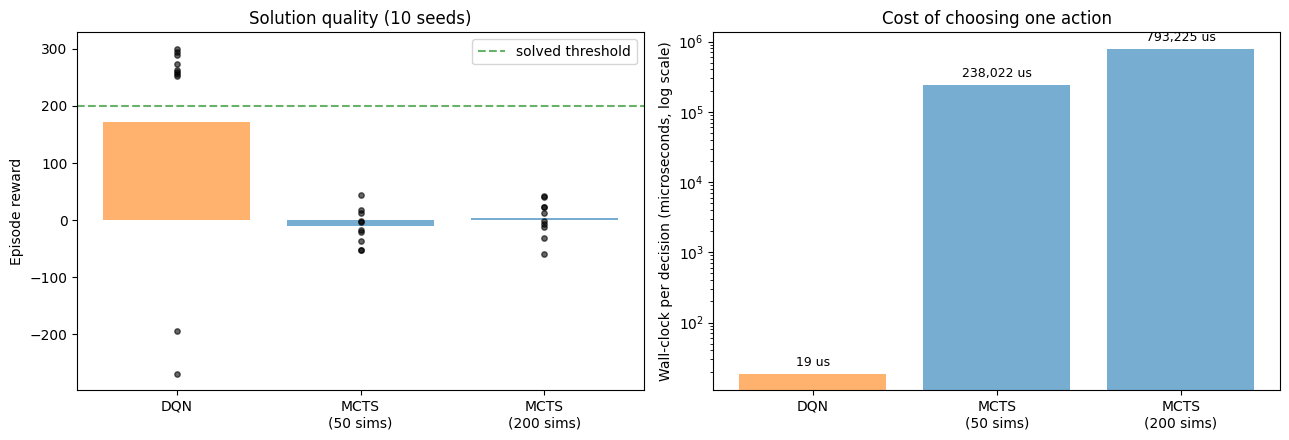

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Reward: bar of means with individual seed points
labels = ["DQN", "MCTS\n(50 sims)", "MCTS\n(200 sims)"]
data = [dqn_rewards, mcts50_rewards, mcts200_rewards]
colors = ["C1", "C0", "C0"]
for i, (d, c) in enumerate(zip(data, colors)):
    axes[0].bar(i, d.mean(), color=c, alpha=0.6)
    axes[0].scatter(np.full_like(d, i, dtype=float), d, color="k", s=15, zorder=3, alpha=0.6)
axes[0].axhline(200, color="g", linestyle="--", alpha=0.6, label="solved threshold")
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Episode reward")
axes[0].set_title("Solution quality (10 seeds)")
axes[0].legend()

# Decision time: log-scale bar
dec = [dqn_decision_us, mcts50_dec_ms * 1e3, mcts200_dec_ms * 1e3]
axes[1].bar(range(3), dec, color=["C1", "C0", "C0"], alpha=0.6)
axes[1].set_yscale("log")
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Wall-clock per decision (microseconds, log scale)")
axes[1].set_title("Cost of choosing one action")
for i, v in enumerate(dec):
    axes[1].text(i, v * 1.3, f"{v:,.0f} us", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

### Results Analysis

The two panels capture the tradeoff, and the comparison is deliberately stacked in MCTS's favor.

**Quality.** The trained DQN scores positively on every seed and clears the solved threshold of 200 on most of them. MCTS stays near zero and never solves. Quadrupling its budget from 50 to 200 simulations per step barely moves the average, the problem is the quality of uniform random rollouts, not their quantity.

**Decision cost.** DQN chooses an action in roughly twenty microseconds, a single forward pass. MCTS at 200 simulations spends close to a full second per decision, because it rolls the simulator forward hundreds of times at every step. That is tens of thousands of times more expensive per action.

So even when we hand MCTS far more compute than DQN, both up front (it needs a perfect simulator) and per decision (a second versus twenty microseconds), it still performs much worse on LunarLander. Learning, having paid its training cost once, both acts faster and acts better here.

### Reading the Tradeoff

Neither algorithm is simply better. They price the same capability differently.

| | MCTS (planning) | DQN (learning) |
| --- | --- | --- |
| Training cost | none | high, paid once |
| Needs a model or simulator | yes | no, learns from samples (but where do they come from?) |
| Cost per decision | high (search every step) | negligible (one forward pass) |
| Adapts to a new task | immediately, just plan | must retrain |
| Quality here | weak even at 200 sims/step | solves the task |

MCTS is the right tool when you have a fast, accurate simulator and can afford to think at decision time, especially in environments where you cannot pre-train. DQN is the right tool when decisions must be cheap and fast at deployment and you can afford to train once on plenty of experience. On LunarLander the second profile clearly wins, but note that the training rollouts have to happen somewhere, and a real moon landing cannot be run 800 times outside of simulation.

An interesting observation is that MCTS failed here for a specific, fixable reason, its rollouts were uninformative. What if we used a learned value function to evaluate leaves instead of rolling out randomly? That single idea is the bridge to the next section.

## The Best of Both Worlds. A Glimpse of AlphaZero

The Lunar Lander experiments left us with a tension. MCTS plans without training but is only as good as its rollouts, and uniform random rollouts in LunarLander were useless. DQN learns a strong value but throws away the ability to look ahead at decision time. The obvious question is whether we can keep the strengths of both.

Recall the four phases of MCTS from Tut05, selection, expansion, simulation, and backup. The **simulation** phase is where the weakness lives. When the search reaches a new leaf $s_\text{leaf}$, classic MCTS estimates that leaf's value by rolling out a random policy to a terminal state and using the return $R_\text{rollout}$.

The fix is to delete the rollout entirely and ask a learned value network instead.
$$R_\text{rollout} \;\longrightarrow\; V_\theta(s_\text{leaf})$$
A single forward pass replaces a long, noisy random simulation. This is the central idea behind AlphaGo and AlphaZero ([Silver et al., 2017](https://www.nature.com/articles/nature24270)).

![alphazero](images/alphazero.png)

### Policy Priors as Heuristics (More ALphaZero)

AlphaZero pushes the same idea one step further and also learns a **policy prior** $P_\theta(s, a)$ that biases which actions the search explores first. The selection rule from Tut05's UCT gains a prior term,
$$a = \arg\max_a \left( Q(s, a) + c \, P_\theta(s, a) \frac{\sqrt{\sum_b N(s, b)}}{1 + N(s, a)} \right),$$
so the network focuses the search on promising actions instead of treating them all equally.

The two networks and the planner train each other in a loop.

- The **planner improves the networks.** MCTS, guided by the current $V_\theta$ and $P_\theta$, produces a stronger action distribution than the raw network. The networks are trained to match that improved distribution and the eventual game outcome.
- The **networks improve the planner.** Better leaf values and better priors make each future search sharper for the same simulation budget.

This is the synthesis the whole course has been building toward. Planning and learning are not competitors. MCTS supplies look-ahead and on-the-fly adaptation, the value network supplies the cheap, informative leaf estimates that random rollouts could not, and the policy network focuses the search. The result mastered Go, chess, and shogi from self-play alone.

We have all the pieces to understand it. Tut05 gave us MCTS, and this tutorial gave us value learning with neural networks. AlphaZero is, in essence, MCTS with the rollout replaced by a DQN-style value network and a learned action prior. Implementing it is beyond our scope here, but it should no longer feel like magic.

## Conclusion

We started from the tabular Q-learning of Tut06 and asked what happens when the state space is too large for a table. The answer was Deep Q-Networks, and the road there was instructive.

- We replaced the Q-table with a neural network and watched naive training **diverge**, a concrete encounter with the deadly triad.
- The **replay buffer** broke the correlation between consecutive samples, and the **target network** stopped us from chasing a moving target. Together they turned a broken algorithm into DQN.
- We exposed the **overestimation** in the $\max$ target on controlled environments, introduced **Double DQN** as the one-line fix, and saw the bias flip a policy from optimal to suboptimal.
- We scaled DQN to **LunarLander**, an 8-dimensional continuous-state environment that classical planning and tabular methods cannot touch, and confirmed there that the overestimation bias was negligible, since it has only four actions and no compounding loop like the fork.
- We put DQN head to head with **MCTS**, making the planning-versus-learning tradeoff concrete, and saw how AlphaZero fuses the two.

**What DQN gives us.**

- It scales value-based RL far beyond tabular methods, generalizing across similar states.
- It is model-free, learning directly from experience with no simulator required.
- Once trained, decisions are a single forward pass, microseconds per action.
- Off-policy replay lets it reuse old experience many times.

**What it costs, and where it breaks.**

- It is sample-hungry and needs the replay buffer and target network to stay stable.
- It is sensitive to hyperparameters, the buffer size, target-sync interval, and exploration schedule all matter.
- Most fundamentally, the policy is $\arg\max_a Q_\theta(s, a)$, an enumeration over actions. That is fine for a handful of discrete actions but **does not extend to continuous action spaces**, where you cannot enumerate the max.

That last limitation is the doorway to the next tutorial. When actions are continuous, we stop representing the policy implicitly through a value function and start representing it directly. That is the world of **policy-based methods**, where a we directly output actions and optimize the policy directly.

The larger lesson is the one this course keeps returning to. Planning and learning are two routes to the same goal of good decisions, with complementary strengths, and the most powerful methods combine them.